In [1]:
#setup 

import torch
import random
import matplotlib.pyplot as plt
import torchvision
from torch import nn
from torch.autograd import Variable
from torch.utils.data import DataLoader, random_split
from torchvision import transforms, datasets
from torchvision.utils import save_image, make_grid
from torchvision.datasets import FashionMNIST
import os

if not os.path.exists('./ExperimentOne_img'):
    os.mkdir('./ExperimentOne_img')
    
print ("setup done")

setup done


In [2]:
#helper functions
def to_img(x):
    x = 0.5 * (x + 1)
    x = x.clamp(0, 1)
    return x

In [3]:
#hyperparameters
num_epochs = 10 #each epoch has a runtime of approx. 4 min
batch_size = 128
learning_rate = 1e-3

markdown the data set cell that will not be used.
user must set USE_XRAY_VAL in Xray data set to true or false depeinding on if the run is for train or validation

#Fashion MINST Data loading and data set

img_transform = transforms.Compose([
    transforms.Resize((128, 128)), #we want the input images of both FashionMINST and xray to be of same size so that model can work on both. we are using transpose convelution in recostruction so the output size must be equal ti input size in order to compute the loss. hence standarize both datasets to same size
    transforms.ToTensor(),
    transforms.Normalize((0.5), (0.5))
])
full_fashion_dataset = FashionMNIST('./FashionMNIST', train=True, transform=img_transform, download=True)
train_size = int(0.8 * len(full_fashion_dataset)) #80%
val_size = len(full_fashion_dataset) - train_size   # 20%
train_fashion_dataset, val_fashion_dataset = random_split(full_fashion_dataset, [train_size, val_size],generator=torch.Generator().manual_seed(42)) #so that train data and validation data remain the same across different runs
print("fashion Training samples:", len(train_fashion_dataset))
print("fashion Validation samples:", len(val_fashion_dataset))

train_dataloader = DataLoader(train_fashion_dataset, batch_size=batch_size, shuffle=True)
print("Number of training batches:", len(train_dataloader))


val_dataloader = DataLoader(val_fashion_dataset, batch_size=batch_size, shuffle=True)
print("Number of validation batches:", len(val_dataloader))






In [4]:
#Chest xray data loading and data set

img_transform = transforms.Compose([
    transforms.Resize((128, 128)),  
    transforms.Grayscale(num_output_channels=1),  # ensure 1 channel like FashionMINST
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

xray_train_dataset = datasets.ImageFolder('./chest_xray/train', transform=img_transform)
print("xray Training samples:", len(xray_train_dataset))
train_dataloader = DataLoader(xray_train_dataset, batch_size=batch_size, shuffle=True)
print("Number of training batches:", len(train_dataloader))

xray_val_dataset = datasets.ImageFolder('./chest_xray/val', transform=img_transform)
print("xray Validation samples:", len(xray_val_dataset))
val_dataloader = DataLoader(xray_val_dataset, batch_size=batch_size, shuffle=True)
print("Number of validation batches:", len(val_dataloader))

xray Training samples: 5216
Number of training batches: 41
xray Validation samples: 16
Number of validation batches: 1


In [5]:
#add noise to the image
def add_noise(img, sigma=0.2):
    noise = torch.randn_like(img) * sigma
    noisy_img = img + noise
    noisy_img = torch.clamp(noisy_img, -1., 1.)  # keep same range
    return noisy_img

In [6]:
# Model definition
class autoencoder(nn.Module):
    def __init__(self):
        super(autoencoder, self).__init__()
        
        # -------- Encoder --------
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, 3, stride=1, padding=1),   # 32 x 128 x 128
            nn.ReLU(True),
            nn.MaxPool2d(2, stride=2),                  # 32 x 64 x 64

            nn.Conv2d(32, 64, 3, stride=1, padding=1),  # 64 x 64 x 64
            nn.ReLU(True),
            nn.MaxPool2d(2, stride=2),                  # 64 x 32 x 32

            nn.Conv2d(64, 32, 3, stride=1, padding=1),  # 32 x 32 x 32
            nn.ReLU(True),
            nn.MaxPool2d(2, stride=2)                   # 32 x 16 x 16  ← bottleneck
        )
        
        # -------- Decoder --------
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(32, 64, 2, stride=2),    # 64 x 32 x 32
            nn.ReLU(True),

            nn.ConvTranspose2d(64, 32, 2, stride=2),    # 32 x 64 x 64
            nn.ReLU(True),

            nn.ConvTranspose2d(32, 16, 2, stride=2),    # 16 x 128 x 128
            nn.ReLU(True),

            nn.ConvTranspose2d(16, 1, 3, stride=1, padding=1),  # 1 x 128 x 128
            nn.Tanh()
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

print("model defined")

model defined


In [7]:
#Model and optimizer
model = autoencoder()

# load model if exists
if os.path.exists("exp1_model.pth"):
    data = torch.load("exp1_model.pth")

    model.load_state_dict(data['model_state_dict'])
    exp1_val_loss = data['exp1_val_loss']

    print("Loaded previous model weights")
    print(f"Loaded exp1_val_loss: {exp1_val_loss:.4f}")

    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate,
                                 weight_decay=1e-5)
    optimizer.load_state_dict(data['optimizer'])
    #redusing the learning rate for a run when oscialltion is seen in a prior run
    for param_group in optimizer.param_groups: 
        param_group['lr'] = 1e-4

else:
    exp1_val_loss = float('inf') #infinity value for initial exp1 val so that any val loss in first run is less than it

    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate,
                                 weight_decay=1e-5)
    
criterion = nn.MSELoss()

Loaded previous model weights
Loaded exp1_val_loss: 0.0063


In [8]:
#detect the last run number from ExperimentOne_img folder so that images saved in it are based on run number and repective epoch within the run.
save_path = "./ExperimentOne_img"

existing_files = os.listdir(save_path)

run_ids = []

for f in existing_files:
    if "run" in f:
        try:
            run_num = int(f.split("run_")[1].split("_")[0])
            run_ids.append(run_num)
        except:
            pass

run_id = max(run_ids) + 1 if run_ids else 1

print(f"Starting Run {run_id}")

Starting Run 5


In [9]:
#save locally a grid of size 9X8 where first 3 rows are original images, later 3 rows are their respective noisy versions, later 3 rows are their respective reconstruced versions
#images are randomly selected from same batch
train=True #inital value, will be updated in the training loop to differentiate between training and validation images when saving the grid.
def save_comparison_grid(img, noisy_img, output, epoch, save_path="./ExperimentOne_img"):
    
    num_cols = 8
    num_imgs = num_cols * 3   #24 images → 3 rows per category

    #random selection (same indices for all 3 types)
    indices = torch.randperm(img.size(0))[:num_imgs]

    orig_imgs = img[indices]
    noisy_imgs = noisy_img[indices]
    recon_imgs = output[indices]

    #convert to [0,1]
    orig_imgs = to_img(orig_imgs)
    noisy_imgs = to_img(noisy_imgs)
    recon_imgs = to_img(recon_imgs)

    #stack: orig below it is noisy below it is recon
    grid_imgs = torch.cat([orig_imgs, noisy_imgs, recon_imgs], dim=0)

    #create grid
    grid = make_grid(grid_imgs, nrow=num_cols)

    #save
    if train:
        save_image(grid, f"{save_path}/training_run_{run_id}_epoch_{epoch}.png")
    if not train:
        save_image(grid, f"{save_path}/validation_run_{run_id}_epoch_{epoch}.png") 
    return grid

In [10]:
#saving the loss of cuurrent run so that in next run it gets appended to the new loss in the loss curve in order to show a representative learning flow
train_loss_file = "losses.pt"
val_loss_file = "val_losses.pt"
#load train losses
if os.path.exists(train_loss_file):
    train_losses = torch.load(train_loss_file)
    print(f"Loaded previous losses: {len(train_losses)} points")
else:
    train_losses = [] 
# Load validation losses 
if os.path.exists(val_loss_file):
    val_losses = torch.load(val_loss_file)
    print(f"Loaded val losses: {len(val_losses)} points")
else:
    val_losses = []


Loaded previous losses: 40 points
Loaded val losses: 40 points


Training 
Epoch [1/10], Loss: 0.0069


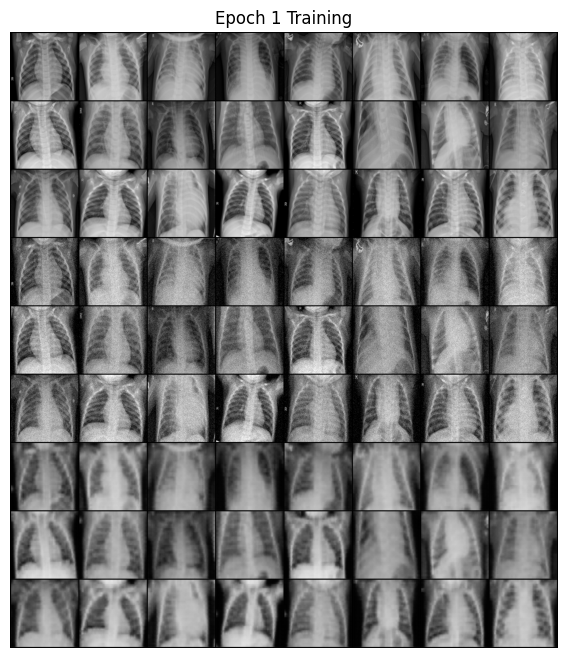

Validation 
Epoch [1/10], val_Loss: 0.0063


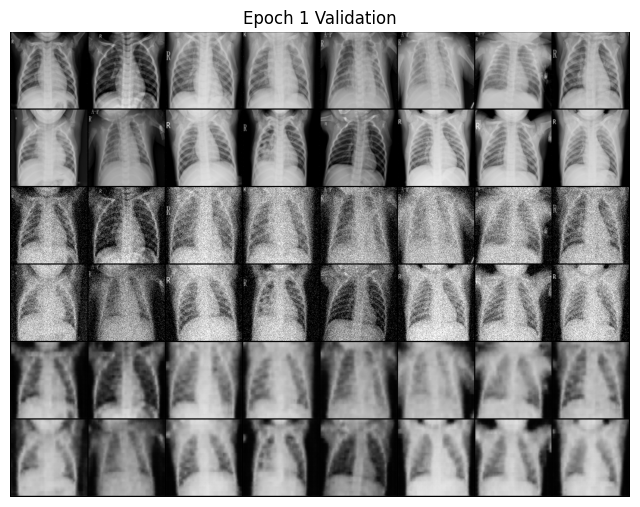

 Saved exp1 model at epoch 1 with val loss 0.0063
Training 
Epoch [2/10], Loss: 0.0072
Validation 
Epoch [2/10], val_Loss: 0.0064
Training 
Epoch [3/10], Loss: 0.0069
Validation 
Epoch [3/10], val_Loss: 0.0063
 Saved exp1 model at epoch 3 with val loss 0.0063
Training 
Epoch [4/10], Loss: 0.0071
Validation 
Epoch [4/10], val_Loss: 0.0063
Training 
Epoch [5/10], Loss: 0.0069
Validation 
Epoch [5/10], val_Loss: 0.0063
Training 
Epoch [6/10], Loss: 0.0070
Validation 
Epoch [6/10], val_Loss: 0.0064
Training 
Epoch [7/10], Loss: 0.0069
Validation 
Epoch [7/10], val_Loss: 0.0063
 Saved exp1 model at epoch 7 with val loss 0.0063
Training 
Epoch [8/10], Loss: 0.0068
Validation 
Epoch [8/10], val_Loss: 0.0063
Training 
Epoch [9/10], Loss: 0.0072
Validation 
Epoch [9/10], val_Loss: 0.0063
Training 
Epoch [10/10], Loss: 0.0069


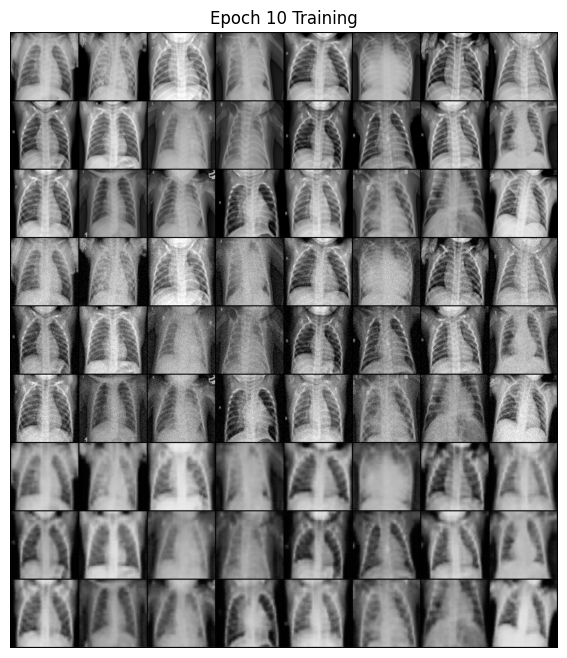

Validation 
Epoch [10/10], val_Loss: 0.0063


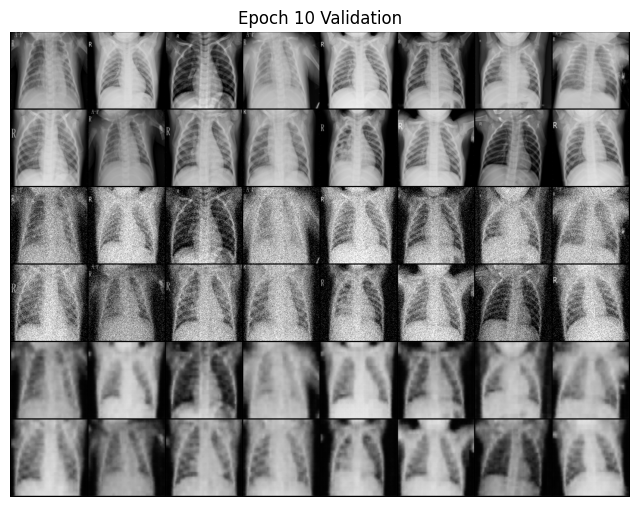

 Saved exp1 model at epoch 10 with val loss 0.0063


In [11]:
#Training and validation loop
#for each epoch, train,update weights, then vlaidate.
#save the model with least validation loss as exp1 model.

for epoch in range(num_epochs):
        #Training 
        print("Training ")
        train= True
        model.train()
        total_train_loss = 0
        for data in train_dataloader:
            img, _ = data
            img = Variable(img)
            sigma = random.choice([0.1, 0.2, 0.3])
            noisy_img = add_noise(img, sigma=sigma)
            # ===================forward=====================
            output = model(noisy_img)
            loss = criterion(output, img)
            # ===================backward====================
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_train_loss += loss.item()
            
        # ===================log========================
        
        avg_train_loss = total_train_loss / len(train_dataloader) #avergae loss per epoch
        train_losses.append(avg_train_loss) #store average loss per epoch for plotting later
        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {avg_train_loss:.4f}") #print the avg loss for each epoch
        if epoch % 10 == 0 or epoch == num_epochs - 1:
            grid = save_comparison_grid(img, noisy_img, output, epoch) #save grid of original, noisy and reconstructed images every 10 epochs
            plt.figure(figsize=(8,8))
            plt.imshow(grid.permute(1, 2, 0))
            plt.title(f"Epoch {epoch+1} Training")
            plt.axis('off')
            plt.show()
        

        ##Validation
        train=False
        model.eval()
        print("Validation ")
        total_val_loss = 0
        with torch.no_grad(): #forward pass only
            for data in val_dataloader:
                img, _ = data
                img = Variable(img)
                sigma = 0.2  #fixed noise level for validation
                noisy_img = add_noise(img, sigma=sigma)
                output = model(noisy_img)
                loss = criterion(output, img)
                total_val_loss += loss.item() 
            avg_val_loss = total_val_loss / len(val_dataloader)  
            val_losses.append(avg_val_loss)
            print(f"Epoch [{epoch+1}/{num_epochs}], val_Loss: {avg_val_loss:.4f}")
            if epoch % 10 == 0 or epoch == num_epochs - 1:
                grid = save_comparison_grid(img, noisy_img, output, epoch) #save grid of original, noisy and reconstructed images every 10 epochs
                plt.figure(figsize=(8,8))
                plt.imshow(grid.permute(1, 2, 0))
                plt.title(f"Epoch {epoch+1} Validation")
                plt.axis('off')
                plt.show()
        #save model with least validation loss as exp1 model
        if avg_val_loss < exp1_val_loss:
            exp1_val_loss = avg_val_loss
            torch.save({
            'model_state_dict': model.state_dict(),
            'exp1_val_loss': exp1_val_loss, 'optimizer': optimizer.state_dict(),
             }, "exp1_model.pth")

            print(f" Saved exp1 model at epoch {epoch+1} with val loss {exp1_val_loss:.4f}")
        

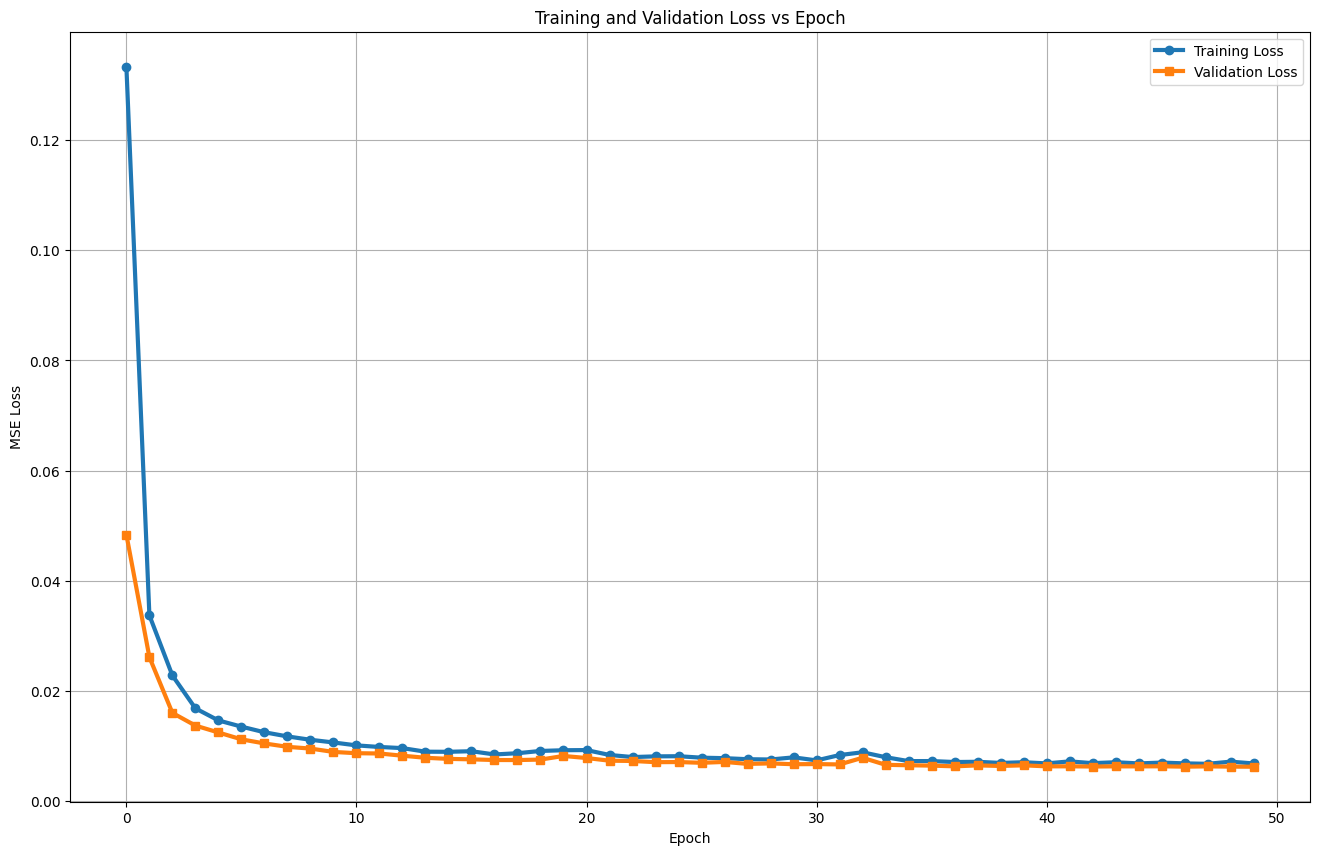

In [12]:
#plotting the trainloss and validation loss curve

plt.figure(figsize=(16,10))
plt.plot(train_losses, marker='o', linewidth=3, label='Training Loss')
plt.plot(val_losses, marker='s', linewidth=3, label='Validation Loss')
plt.title("Training and Validation Loss vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.grid(True)
plt.show()

In [13]:


torch.save(train_losses, train_loss_file)
print("Saved updated training loss history")
torch.save(val_losses, val_loss_file)
print("Saved updated val_loss history")

Saved updated training loss history
Saved updated val_loss history



=== Experiment Results (exp1 runs 1–5) ===
 Epoch  Run1_Train  Run1_Val  Run2_Train  Run2_Val  Run3_Train  Run3_Val  Run4_Train  Run4_Val  Run5_Train  Run5_Val
     1      0.1333    0.0484      0.0102    0.0087      0.0093    0.0079      0.0074    0.0068      0.0069    0.0063
     2      0.0337    0.0262      0.0099    0.0087      0.0084    0.0074      0.0084    0.0067      0.0072    0.0064
     3      0.0228    0.0160      0.0097    0.0083      0.0080    0.0073      0.0089    0.0079      0.0069    0.0063
     4      0.0169    0.0137      0.0090    0.0079      0.0082    0.0071      0.0080    0.0066      0.0071    0.0063
     5      0.0147    0.0125      0.0090    0.0077      0.0082    0.0071      0.0073    0.0065      0.0069    0.0063
     6      0.0136    0.0112      0.0091    0.0076      0.0079    0.0070      0.0073    0.0065      0.0070    0.0064
     7      0.0125    0.0105      0.0085    0.0075      0.0078    0.0071      0.0071    0.0063      0.0069    0.0063
     8      0.0118  

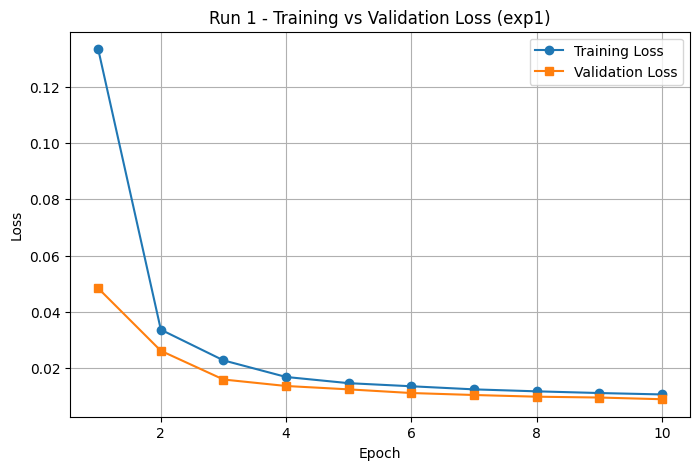

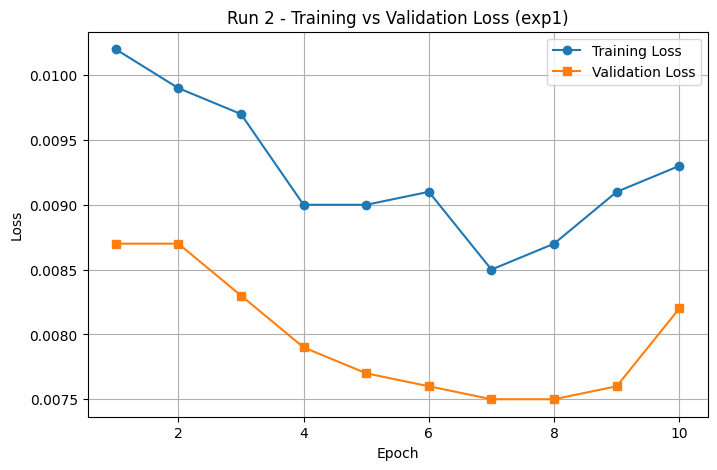

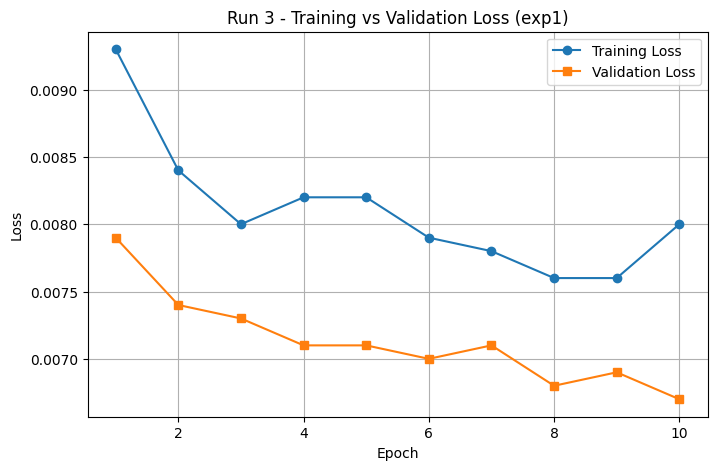

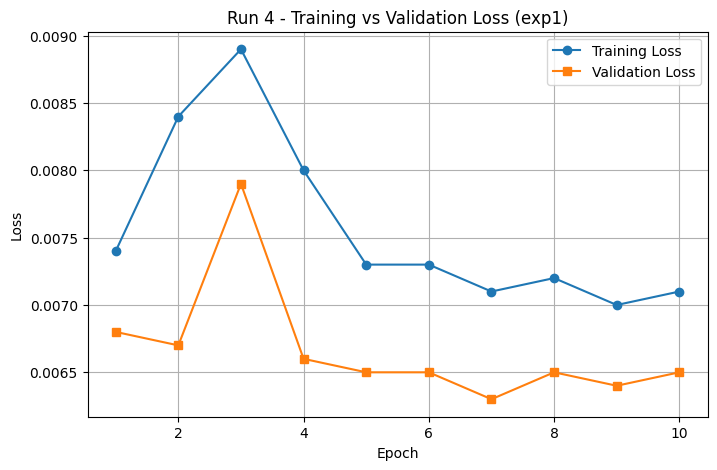

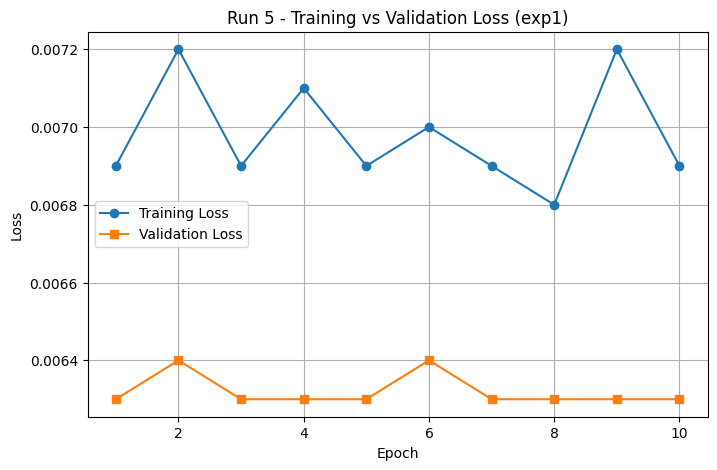

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

# Hardcoded data from your latest logs (Runs 1–5)
data = {
    "Epoch": list(range(1, 11)),

    "Run1_Train": [0.1333, 0.0337, 0.0228, 0.0169, 0.0147, 0.0136, 0.0125, 0.0118, 0.0112, 0.0107],
    "Run1_Val":   [0.0484, 0.0262, 0.0160, 0.0137, 0.0125, 0.0112, 0.0105, 0.0099, 0.0096, 0.0090],

    "Run2_Train": [0.0102, 0.0099, 0.0097, 0.0090, 0.0090, 0.0091, 0.0085, 0.0087, 0.0091, 0.0093],
    "Run2_Val":   [0.0087, 0.0087, 0.0083, 0.0079, 0.0077, 0.0076, 0.0075, 0.0075, 0.0076, 0.0082],

    "Run3_Train": [0.0093, 0.0084, 0.0080, 0.0082, 0.0082, 0.0079, 0.0078, 0.0076, 0.0076, 0.0080],
    "Run3_Val":   [0.0079, 0.0074, 0.0073, 0.0071, 0.0071, 0.0070, 0.0071, 0.0068, 0.0069, 0.0067],

    "Run4_Train": [0.0074, 0.0084, 0.0089, 0.0080, 0.0073, 0.0073, 0.0071, 0.0072, 0.0070, 0.0071],
    "Run4_Val":   [0.0068, 0.0067, 0.0079, 0.0066, 0.0065, 0.0065, 0.0063, 0.0065, 0.0064, 0.0065],

    "Run5_Train": [0.0069, 0.0072, 0.0069, 0.0071, 0.0069, 0.0070, 0.0069, 0.0068, 0.0072, 0.0069],
    "Run5_Val":   [0.0063, 0.0064, 0.0063, 0.0063, 0.0063, 0.0064, 0.0063, 0.0063, 0.0063, 0.0063],
}

# Convert to DataFrame
df = pd.DataFrame(data)

# Show the table in terminal instead of saving
print("\n=== Experiment Results (exp1 runs 1–5) ===")
print(df.to_string(index=False))

# Plot each run separately
for run in range(1, 6):
    train_col = f"Run{run}_Train"
    val_col = f"Run{run}_Val"

    plt.figure(figsize=(8,5))
    plt.plot(df["Epoch"], df[train_col], marker='o', label="Training Loss")
    plt.plot(df["Epoch"], df[val_col], marker='s', label="Validation Loss")

    plt.title(f"Run {run} - Training vs Validation Loss (exp1)")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)

    plt.show()
